# 时间序列

时间序列数据是一种重要的结构化数据形式，应用于多个领域，包括金融学、经济学、生态学、神经科学、物理学等。在多个时间点重复记录的值就形成了时间序列。很多时间序列是固定频率的，也就是说，数据点是根据某种规则定期出现的，比如每15秒、每5分钟或每月一次。时间序列也可以是不定期的，没有固定的时间单位或单位之间的偏移量。如何标记和引用时间序列数据取决于具体的应用，主要有以下几种：

- 时间戳
- 特定的时刻。
- 固定的周期
- 如2017年1月整月或2020年全年。
- 时间区间
- 由起始时间戳和结束时间戳表示。周期可以看作时间区间的特例。
- 试验时间或运行时间

每个时间戳都是相对于特定起始时间的度量（例如，饼干放入烤箱后每秒烘烤的直径），从0开始。

本章主要讲解前三种时间序列。许多技术都可用于处理试验时间序列，其索引可能是整数或浮点数，表示距试验起始时刻已经过去的时间。最简单的时间序列是按时间戳索引的。

## 11.1 日期和时间数据的类型及工具

Python标准库包含用于日期和时间数据的数据类型，并且还包含日历相关的功能。我们主要会用到datetime、time以及calendar模块。datetime.datetime（简写为datetime）是使用广泛的数据类型：

In [2]:
from datetime import datetime

now = datetime.now()
now

datetime.datetime(2025, 11, 27, 21, 59, 47, 343572)

In [3]:
now.year, now.month, now.day

(2025, 11, 27)

datetime以毫秒形式存储日期和时间。datetime.timedelta表示两个datetime对象之间的时间差：

In [4]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)
delta

datetime.timedelta(days=926, seconds=56700)

In [5]:
delta.days, delta.seconds

(926, 56700)

可以给datetime对象加上（或减去）一个或多个timedelta，这样会生成一个新的偏移对象：

In [6]:
from datetime import timedelta

start = datetime(2011, 1, 7)
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [7]:
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

**datetime模块中的数据类型：**
![表11-1 datetime模块中的数据类型.png](<attachment:表11-1 datetime模块中的数据类型.png>)
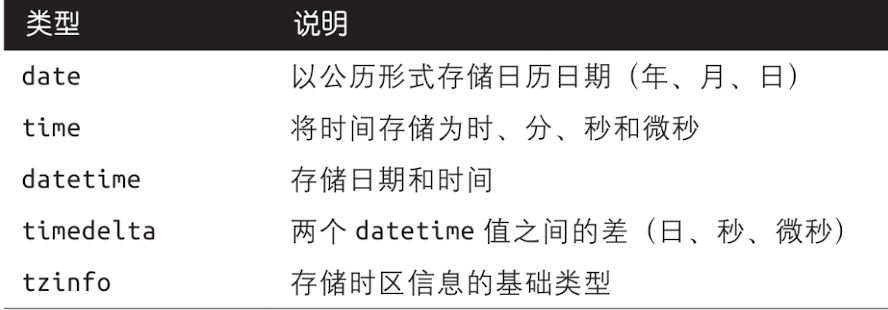

**字符串和datetime的相互转换**

利用str或strftime方法并传入指定格式，可以将datetime对象和pandas的Timestamp对象（稍后就会介绍）格式化为字符串：

In [8]:
stamp = datetime(2011, 1, 3)
str(stamp)

'2011-01-03 00:00:00'

In [9]:
stamp.strftime('%Y-%m-%d')

'2011-01-03'

**datetime格式说明：**
| 类型 | 说明 |
|-----|------|
| %Y | 四位数的年 |
| %y | 两位数的年 |
| %m | 两位数的月 |
| %d | 两位数的日 |
| %H | 两位数的小时 |
| %I | 12小时制的小时 |
| %M | 两位数的分钟 |
| %S | 两位数的秒 |
| %f | 整数形式的微秒，零填充（从000000到999999） |
| %w | 一周的第几天，0(星期天)-6 |
| %u | 一周的第几天，1-7 |
| %U | 一年的第几周，0-53，星期天作为每周的第一天，每年第一个星期天之前的若干天属于第0周 |
| %W | 一年的第几周，0-53，星期一作为每周的第一天，每年第一个星期一之前的若干天属于第0周 |
| %z | UTC时区偏移量，如+08:00，如果没有时区则为空字符串 |
| %Z | UTC时区名称，如果没有时区则为空字符串 |
| %j | 一年的第几天，零填充，001-366 |
| %a | 星期中的星期几，Mon-Sun |
| %F | 等同于%Y-%m-%d，例如，2023-01-01 |
| %D | 等同于%m/%d/%y，例如，04/18/23 |

使用datetime.strptime和这些格式编码（但不能使用某些编码，比如%F），可以将字符串转换为日期：

In [10]:
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d')

datetime.datetime(2011, 1, 3, 0, 0)

In [11]:
datestrs = ['7/6/2011', '8/6/2011']
[datetime.strptime(x, '%m/%d/%Y') for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

datetime.strptime是通过已知格式来解析日期的。

pandas通常用于处理日期数组，不管这些日期是DataFrame的轴索引还是列。pandas.to_datetime方法可以解析多种不同的日期表示形式。对标准日期格式（如ISO 8601）的解析非常快：

In [12]:
import pandas as pd

datestrs = ['2011-07-06 12:00:00', '2011-08-06 00:00:00']
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

pandas.to_datetime方法还可以处理应当作为缺失值的值（None、空字符串等）：

In [13]:
idx = pd.to_datetime(datestrs + [None])
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [14]:
idx.isna()

array([False, False,  True])

NaT(Not a Time)用于表示pandas中时间戳数据的空值。

dateutil.parser是一个实用但不完美的工具，尤其是它会把一些原本不是日期的字符串认作日期（比如"42"会被解析为2042年的当前日期）。
针对不同国家或使用不同语言的系统，datetime对象还有一些本地化格式选项。例如，德语或法语系统所用的月份简写就与英语系统所用的不同。表11-3进行了总结。

**表11-3 特定地区的日期格式化**
![表11-3 特定地区的日期格式化.png](<attachment:表11-3 特定地区的日期格式化.png>)
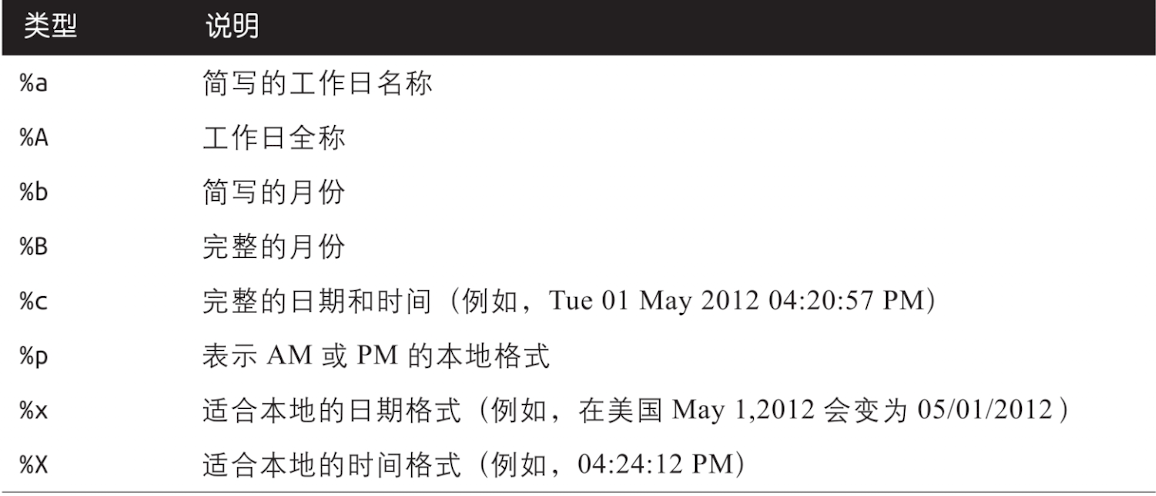

## 11.2 时间序列基础知识

pandas最基本的时间序列类型就是以时间戳为索引的Series，时间戳通常以Python字符串或datatime对象表示：

In [15]:
import numpy as np
import pandas as pd
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
          datetime(2011, 1, 7), datetime(2011, 1, 8),
          datetime(2011, 1, 10), datetime(2011, 1, 12)]
ts = pd.Series(np.random.randn(6), index=dates)

ts

2011-01-02   -0.837878
2011-01-05   -0.359368
2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
2011-01-12    0.268582
dtype: float64

在底层，这些datetime对象实际上是放在DatetimeIndex中的：

In [16]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

与其他Series一样，不同索引的时间序列之间的算术运算会自动按日期对齐：

In [17]:
ts + ts[::2]

2011-01-02   -1.675757
2011-01-05         NaN
2011-01-07   -1.180488
2011-01-08         NaN
2011-01-10    2.584850
2011-01-12         NaN
dtype: float64

### 11.2.1 索引、选取、子集构造

当根据标签进行索引和选取数据时，时间序列和其他的Series很像：

In [18]:
stamp = ts.index[2]
stamp

Timestamp('2011-01-07 00:00:00')

In [19]:
ts[stamp]

np.float64(-0.5902437794075865)

为了方便，也可以传入一个可以解释为日期的字符串：

In [20]:
ts['2011-01-10']

np.float64(1.292425172684051)

对于较长的时间序列，只需传入“年”或“年月”即可轻松选取数据的切片（11.3.1节会详细讨论pandas.date_range）：

In [21]:
long_ts = pd.Series(np.random.standard_normal(1000),
                    index=pd.date_range('2000-01-01', periods=1000))
long_ts

2000-01-01   -1.186047
2000-01-02    0.286914
2000-01-03    1.282743
2000-01-04    0.771092
2000-01-05    1.407938
                ...   
2002-09-22   -0.549849
2002-09-23   -0.102116
2002-09-24    0.811808
2002-09-25   -0.992664
2002-09-26   -0.228352
Freq: D, Length: 1000, dtype: float64

In [22]:
long_ts['2000']

2000-01-01   -1.186047
2000-01-02    0.286914
2000-01-03    1.282743
2000-01-04    0.771092
2000-01-05    1.407938
                ...   
2000-12-27   -0.660591
2000-12-28   -0.923452
2000-12-29    0.158097
2000-12-30    1.119140
2000-12-31    0.252422
Freq: D, Length: 366, dtype: float64

这里，字符串"2001"被解释为年，并选取出该时间范围的数据。如果指定月份，也可以选取数据：

In [23]:
long_ts['2000-05']

2000-05-01   -1.427651
2000-05-02   -2.034048
2000-05-03   -0.875686
2000-05-04    0.164036
2000-05-05    0.739116
2000-05-06    0.790937
2000-05-07   -0.391594
2000-05-08   -0.198052
2000-05-09   -0.680944
2000-05-10    0.423839
2000-05-11   -0.017298
2000-05-12   -0.419947
2000-05-13   -1.097499
2000-05-14    0.188712
2000-05-15   -1.538756
2000-05-16    0.259259
2000-05-17    1.112764
2000-05-18    1.560498
2000-05-19   -0.937303
2000-05-20    0.546188
2000-05-21    0.445634
2000-05-22    1.284722
2000-05-23    0.026045
2000-05-24    1.146396
2000-05-25   -0.269618
2000-05-26    0.825280
2000-05-27   -0.000437
2000-05-28   -1.454165
2000-05-29   -1.744226
2000-05-30    0.496536
2000-05-31    0.712456
Freq: D, dtype: float64

datetime对象也可以进行切片：

In [24]:
ts[datetime(2011, 1, 7):]

2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
2011-01-12    0.268582
dtype: float64

In [25]:
ts[datetime(2011, 1, 7): datetime(2011, 1, 10)]

2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
dtype: float64

由于大部分时间序列数据都是按照时间先后排序的，因此也可以用不存在于该时间序列中的时间戳对其进行范围查询：

In [26]:
ts

2011-01-02   -0.837878
2011-01-05   -0.359368
2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
2011-01-12    0.268582
dtype: float64

In [27]:
ts['2011-01-06':'2011-01-11']

2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
dtype: float64

与之前一样，可以传入字符串日期、datetime或Timestamp。注意，这样切片所产生的是原时间序列的视图，与NumPy数组的切片运算是一样的。这意味着不会复制数据，对切片进行修改会反映到原始数据上。

此外，还有一个等价的实例方法truncate，也可以截取两个日期之间的Series：

In [28]:
ts.truncate(after='2011-01-09')

2011-01-02   -0.837878
2011-01-05   -0.359368
2011-01-07   -0.590244
2011-01-08    1.712778
dtype: float64

所有这些操作对DataFrame也有效，并对DataFrame的行进行索引：


In [29]:
dates = pd.date_range('2000-01-01', periods=100, freq='W-WED')
long_df = pd.DataFrame(np.random.randn(100, 4),
                          index=dates,
                          columns=['A', 'B', 'C', 'D'])
long_df.loc['2000-05']

,A,B,C,D
2000-05-03,-1.004571,0.130842,-1.212050,0.191719
2000-05-10,-2.145947,-0.086947,-1.179469,-0.388881
2000-05-17,0.241985,-0.210343,-1.451740,-0.568909
2000-05-24,-0.409932,-0.701907,2.177810,1.016092
2000-05-31,0.636501,-1.221704,-1.028141,1.102841


### 11.2.2 带有重复索引的时间序列

在某些应用场景中，可能会存在多个观测数据落在同一个时间点上的情况。下面就是一个例子：

In [30]:
dates = pd.DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-02',
                            '2000-01-02', '2000-01-03'])
dup_ts = pd.Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

通过检查索引的is_unique属性，就可以知道索引是不是唯一的：

In [31]:
dup_ts.index.is_unique

False

对这个时间序列进行索引，取决于时间戳是否重复，要么生成标量值，要么生成切片：

In [32]:
dup_ts['2000-01-03']

np.int64(4)

In [33]:
dup_ts['2000-01-02']

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

假设你想对具有重复时间戳的数据进行聚合，一个办法是使用groupby，并传入level=0（存在的唯一层级）：

In [34]:
grouped = dup_ts.groupby(level=0)
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [35]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

## 11.3 日期的范围、频率以及移位

pandas中的原生时间序列一般被认为是不规则的，也就是说，它们没有固定的频率。对于大部分应用程序而言，这是无所谓的。但是，经常需要以某种相对固定的频率进行分析，比如每日、每月、每15分钟等（但这样可能会在时间序列中导入缺失值）。幸好，pandas有一整套标准时间序列频率以及用于重采样（11.6节会详细讨论重采样）、频率推断、生成固定频率日期范围的工具。例如，通过调用resample方法，可以将样本时间序列转换为具有固定日频率的序列：

In [36]:
ts

2011-01-02   -0.837878
2011-01-05   -0.359368
2011-01-07   -0.590244
2011-01-08    1.712778
2011-01-10    1.292425
2011-01-12    0.268582
dtype: float64

In [37]:
resampleer = ts.resample('D')
resampleer

字符串"D"被解释为每日的频率。

频率转换或重采样是一个比较大的主题，详见11.6节。11.6节还将介绍如何使用基本的频率及其倍数。

### 11.3.1 生成日期范围

pandas.date_range还可以用于根据指定频率生成特定长度的DatetimeIndex：


In [38]:
index = pd.date_range('2012-04-01', '2012-06-01')
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

默认情况下，pandas.date_range会生成每日的时间戳。如果只传入起始日期或结束日期，还必须传入要生成的周期个数：

In [39]:
pd.date_range(start='2000-04-01', end='2000-12-01', freq='BM')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/4050700848.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  pd.date_range(start='2000-04-01', end='2000-12-01', freq='BM')


DatetimeIndex(['2000-04-28', '2000-05-31', '2000-06-30', '2000-07-31',
               '2000-08-31', '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

**表11-4 基本的时间序列频率**

![表11-4 基本的时间序列频率.png](<attachment:表11-4 基本的时间序列频率.png>)
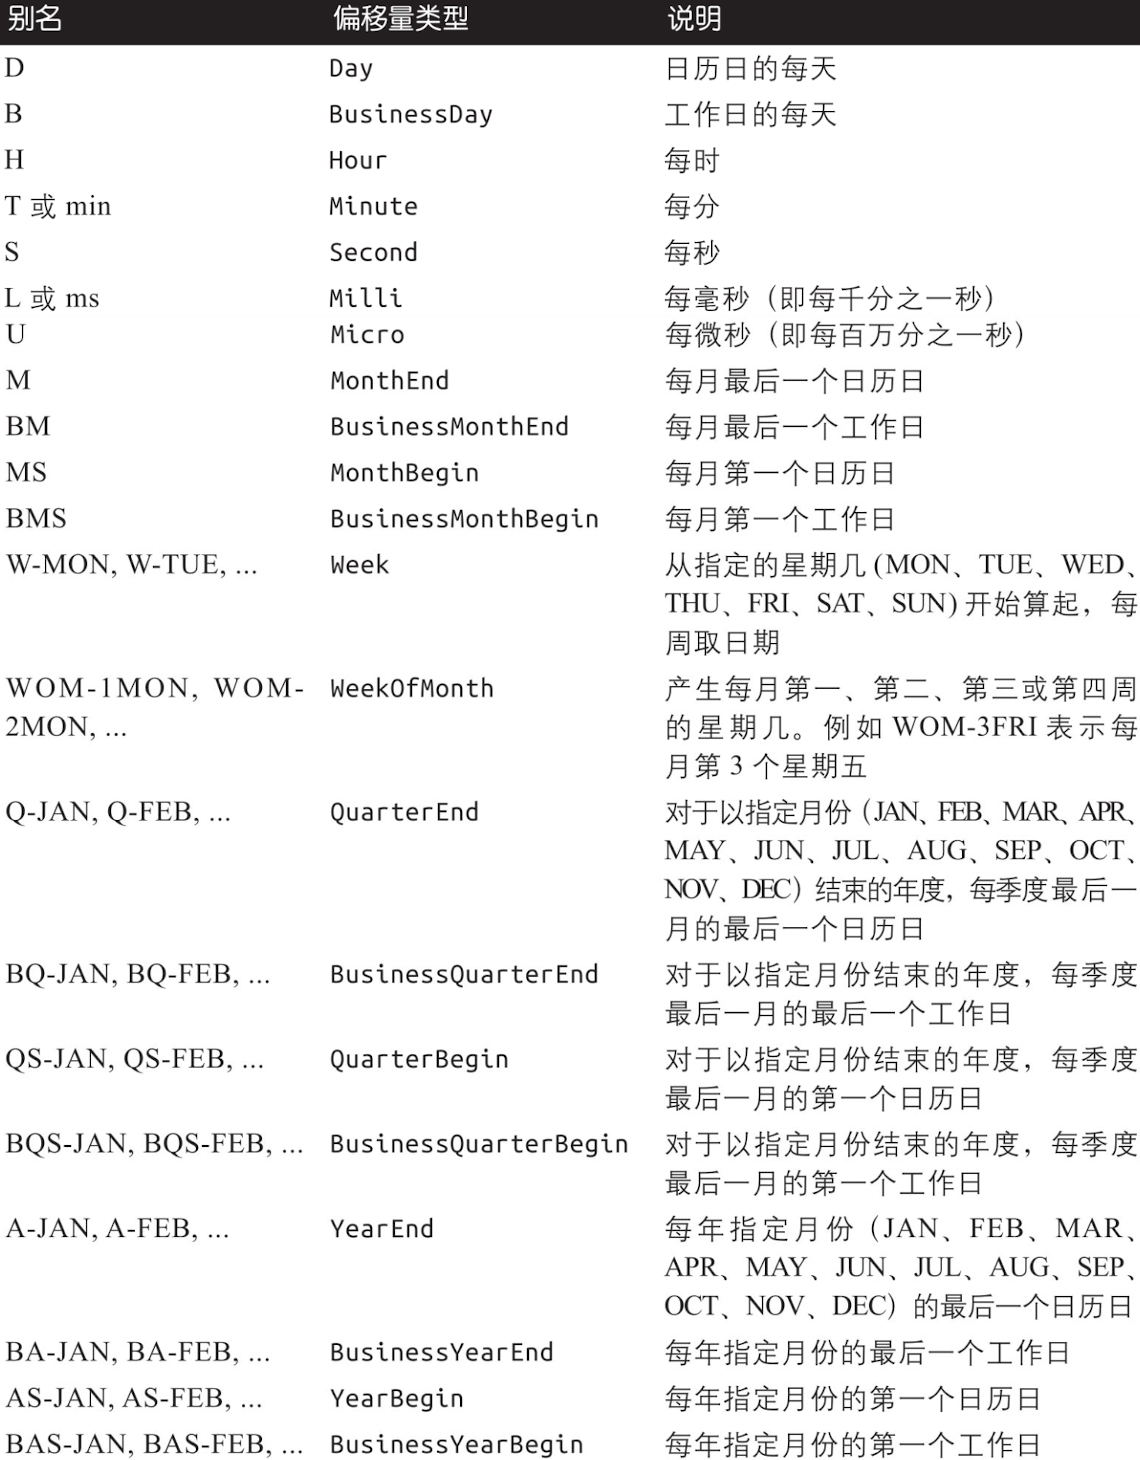

pandas.date_range默认会保留起始时间戳和结束时间戳的时间信息（如果有的话）：

In [40]:
pd.date_range('2012-05-02 12:56:31', periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

有时，虽然起始日期和结束日期带有时间信息，但你希望生成一组标准化到晚间零点的时间戳，normalize选项可以实现该功能：


In [41]:
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

### 11.3.2 频率和日期偏移量

pandas中的频率是由基础频率和倍数组成的。基础频率通常以一个字符串别名表示，比如"M"表示每月，"H"表示每小时。对于每个基础频率，都有一个称为日期偏移量的对象与之对应。例如，每小时的频率可以用Hour类表示：

In [42]:
from pandas.tseries.offsets import Hour, Minute
hour = Hour()
hour

<Hour>

传入一个整数即可定义偏移量的倍数：

In [43]:
four_hours = Hour(4)
four_hours

<4 * Hours>

对于大多数应用，无须显式创建这样的对象，只需使用诸如"H"或"4H"这样的字符串别名。在基础频率前面加上一个整数即可创建倍数：

In [44]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4h')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

大部分偏移量对象都可通过加法进行连接：

In [45]:
Hour(2) + Minute(30)

<150 * Minutes>

同理，也可以传入频率字符串，比如"1h30min"，它可以被高效地解析为等效的表达式：

In [46]:
pd.date_range('2000-01-01', periods=10, freq='1h30min')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

有些频率所描述的时间点并不是均匀分隔的。例如，"M"（每月最后一个日历日）和"BM"（每月最后一个工作日）就取决于每月的天数，对于后者，还要考虑月末是不是周末。我将其称为锚定偏移量。

表11-4列出了pandas中的频率代码和日期偏移量类。

“月中某星期”(Week Of Month)是一种非常实用的频率类，它以WOM开头，使你能获得诸如“每月第3个星期五”之类的日期：

In [47]:
monthly_dates = pd.date_range('2012-01-01', '2012-09-01', freq='WOM-3FRI')

monthly_dates

DatetimeIndex(['2012-01-20', '2012-02-17', '2012-03-16', '2012-04-20',
               '2012-05-18', '2012-06-15', '2012-07-20', '2012-08-17'],
              dtype='datetime64[ns]', freq='WOM-3FRI')

### 11.3.3 对超前和滞后数据进行移位

移位(shifting)是指沿着时间轴将数据前移或后移。Series和DataFrame都有一个shift方法，用于执行单纯的前移或后移操作，并保持索引不变：

In [48]:
ts = pd.Series(np.random.standard_normal(4), 
               index=pd.date_range('2000-01-01', periods=4, freq='M'))

ts

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/3708734930.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range('2000-01-01', periods=4, freq='M'))


2000-01-31   -0.819600
2000-02-29    0.256305
2000-03-31    0.070479
2000-04-30   -0.056982
Freq: ME, dtype: float64

In [49]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.819600
2000-04-30    0.256305
Freq: ME, dtype: float64

In [50]:
ts.shift(-2)

2000-01-31    0.070479
2000-02-29   -0.056982
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

当这样进行移位时，就会在时间序列的前面或后面产生缺失数据。
shift通常用于计算一个时间序列或多个时间序列（如DataFrame的列）中的连续百分比变化。可以这样表达：

ts / ts.shift(1) - 1

￼
由于单纯的移位操作不会修改索引，因此部分数据会被丢弃。如果频率已知，则可以将其传给shift以便实现对时间戳进行移位，而不是对数据进行简单位移：

In [51]:
ts.shift(2, freq='M')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1044886577.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.shift(2, freq='M')


2000-03-31   -0.819600
2000-04-30    0.256305
2000-05-31    0.070479
2000-06-30   -0.056982
Freq: ME, dtype: float64

这里还可以传入其他频率，于是你就能非常灵活地对数据进行超前处理和滞后处理了：

In [52]:
ts.shift(3, freq='D')

2000-02-03   -0.819600
2000-03-03    0.256305
2000-04-03    0.070479
2000-05-03   -0.056982
dtype: float64

In [53]:
ts.shift(1, freq='90T')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/987384525.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ts.shift(1, freq='90T')


2000-01-31 01:30:00   -0.819600
2000-02-29 01:30:00    0.256305
2000-03-31 01:30:00    0.070479
2000-04-30 01:30:00   -0.056982
dtype: float64

**通过偏移量对日期进行移位**
pandas的日期偏移量还可以用在datetime或Timestamp对象上：

In [54]:
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2011, 11, 17)
now + 3 * Day()

Timestamp('2011-11-20 00:00:00')

如果加的是锚定偏移量（比如MonthEnd），第一次增量会将原日期“向前滚动”到符合频率规则的下一个日期：

In [55]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [56]:
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

通过锚定偏移量的rollforward和rollback方法，可显式地将日期向前或向后“滚动”：

In [57]:
offset = MonthEnd()
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [58]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

日期偏移量还有一个巧妙的用法，即结合groupby使用这两个“滚动”方法：

In [59]:
ts = pd.Series(np.random.standard_normal(20),
               index=pd.date_range('2000-01-15', periods=20, freq='4D'))
ts

2000-01-15   -0.266110
2000-01-19   -1.277922
2000-01-23    0.309991
2000-01-27   -0.101398
2000-01-31    0.434320
2000-02-04    1.728639
2000-02-08   -0.611176
2000-02-12    0.544288
2000-02-16    0.607885
2000-02-20    0.388658
2000-02-24    0.798458
2000-02-28    0.898391
2000-03-03   -0.406232
2000-03-07   -0.015018
2000-03-11   -0.889256
2000-03-15   -2.098730
2000-03-19   -0.641172
2000-03-23   -0.333305
2000-03-27    0.404543
2000-03-31    0.818891
Freq: 4D, dtype: float64

In [60]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.180224
2000-02-29    0.622163
2000-03-31   -0.395035
dtype: float64

当然，更简单、更快速地实现该功能的办法是使用resample（11.6节将对此进行详细介绍）：

In [61]:
ts.resample('M').mean()

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/2305925915.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample('M').mean()


2000-01-31   -0.180224
2000-02-29    0.622163
2000-03-31   -0.395035
Freq: ME, dtype: float64

## 11.4 时区处理

时间序列处理工作中最棘手的就是时区处理。因此，许多人都选择以协调世界时(UTC)来处理时间序列，UTC是与地理无关的国际标准时间。时区是以UTC偏移量的形式表示的。例如，夏令时期间，纽约比UTC慢4小时，而在全年其他时间则比UTC慢5小时。

在Python中，时区信息来自第三方库pytz（使用pip或conda进行安装），它使Python可以使用Olson数据库（汇编了世界时区信息）。这对历史数据非常重要，这是因为由于各地政府的各种突发奇想，夏令时转变日期（甚至UTC偏移量）已经发生过多次变化了。就拿美国来说，DST转变时间自1900年以来就变过多次！

有关pytz库的更多信息，请查阅其文档。就本书而言，由于pandas封装了pytz的功能，因此你可以不用记住其API，只要记得时区的名称即可。并且由于已经封装好，因此不必单独安装pytz。时区名可以在终端中查看，也可以通过文档查看

In [62]:
import pytz
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

要从pytz中获取时区对象，使用pytz.timezone即可：

In [63]:
tz = pytz.timezone('America/New_York')
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

### 11.4.1 时区本地化和转换

默认情况下，pandas中的时间序列就是简单的时区。举个例子，考虑下面这个时间序列：

In [64]:
dates = pd.date_range('2012-01-09 09:30', periods=6)

ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)
ts

2012-01-09 09:30:00   -0.918492
2012-01-10 09:30:00    0.657280
2012-01-11 09:30:00   -1.962947
2012-01-12 09:30:00    2.301334
2012-01-13 09:30:00   -0.549866
2012-01-14 09:30:00   -0.018378
Freq: D, dtype: float64

其索引的tz字段为None：


In [65]:
print(ts.index.tz)

None


可以用时区集合生成日期范围：

In [66]:
pd.date_range('2012-03-09', periods=10, tz='UTC')

DatetimeIndex(['2012-03-09 00:00:00+00:00', '2012-03-10 00:00:00+00:00',
               '2012-03-11 00:00:00+00:00', '2012-03-12 00:00:00+00:00',
               '2012-03-13 00:00:00+00:00', '2012-03-14 00:00:00+00:00',
               '2012-03-15 00:00:00+00:00', '2012-03-16 00:00:00+00:00',
               '2012-03-17 00:00:00+00:00', '2012-03-18 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

从简单时区到本地化时区（以特定时区重新观测数据）的转换是通过tz_localize方法实现的：

In [67]:
ts

2012-01-09 09:30:00   -0.918492
2012-01-10 09:30:00    0.657280
2012-01-11 09:30:00   -1.962947
2012-01-12 09:30:00    2.301334
2012-01-13 09:30:00   -0.549866
2012-01-14 09:30:00   -0.018378
Freq: D, dtype: float64

In [68]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-01-09 09:30:00+00:00   -0.918492
2012-01-10 09:30:00+00:00    0.657280
2012-01-11 09:30:00+00:00   -1.962947
2012-01-12 09:30:00+00:00    2.301334
2012-01-13 09:30:00+00:00   -0.549866
2012-01-14 09:30:00+00:00   -0.018378
Freq: D, dtype: float64

In [69]:
ts_utc.index.tz

datetime.timezone.utc

一旦时间序列被本地化到某个特定时区，就可以用tz_convert将其转换到其他时区了：

In [70]:
ts_utc.tz_convert('America/New_York')

2012-01-09 04:30:00-05:00   -0.918492
2012-01-10 04:30:00-05:00    0.657280
2012-01-11 04:30:00-05:00   -1.962947
2012-01-12 04:30:00-05:00    2.301334
2012-01-13 04:30:00-05:00   -0.549866
2012-01-14 04:30:00-05:00   -0.018378
Freq: D, dtype: float64

### 11.4.2 对时区型时间戳对象的操作

类似于时间序列和日期范围，独立的Timestamp对象也能从简单型本地化为时区型，并从一个时区转换到另一个时区：

In [71]:
stamp = pd.Timestamp('2011-03-12 04:00')
stamp_utc = stamp.tz_localize('utc')
stamp_utc

Timestamp('2011-03-12 04:00:00+0000', tz='UTC')

In [72]:
stamp_utc.tz_convert('America/New_York')

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

在创建Timestamp时，还可以传入时区信息：

In [73]:
stamp_moscow = pd.Timestamp('2011-03-12 04:00', tz='Europe/Moscow')
stamp_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

时区型Timestamp对象在内部保存了UTC时间戳值——一个自UNIX纪元（1970年1月1日）算起的纳秒数。因此转换时区不会改变内部UTC值：

In [74]:
stamp_utc.value

1299902400000000000

In [75]:
stamp_utc.tz_convert('America/New_York').value

1299902400000000000

### 11.4.3 不同时区之间的运算

如果两个时间序列的时区不同，在将它们合并到一起时，最终结果就会是UTC。由于时间戳其实是存储在UTC内部的，因此这是个直接运算，不需要做任何转换：

In [76]:
dates = pd.date_range('2012-03-07 09:30', periods=10, freq='B')

ts = pd.Series(np.random.standard_normal(len(dates)), index=dates)

ts

2012-03-07 09:30:00   -1.037720
2012-03-08 09:30:00   -0.270102
2012-03-09 09:30:00   -0.994255
2012-03-12 09:30:00    1.582259
2012-03-13 09:30:00   -0.299210
2012-03-14 09:30:00    0.013391
2012-03-15 09:30:00   -1.217159
2012-03-16 09:30:00    1.077475
2012-03-19 09:30:00    1.749173
2012-03-20 09:30:00    1.103634
Freq: B, dtype: float64

In [77]:
ts1 = ts[:7].tz_localize('Europe/London')
ts2 = ts1[2:].tz_convert('Europe/Moscow')

result = ts1 + ts2
result

2012-03-07 09:30:00+00:00         NaN
2012-03-08 09:30:00+00:00         NaN
2012-03-09 09:30:00+00:00   -1.988509
2012-03-12 09:30:00+00:00    3.164517
2012-03-13 09:30:00+00:00   -0.598420
2012-03-14 09:30:00+00:00    0.026783
2012-03-15 09:30:00+00:00   -2.434318
dtype: float64

简单型和时区型的对象间不支持运算，如果运算将会抛出异常。

## 11.5 周期及其算术运算

周期表示的是时间段，比如数日、数月、数季、数年等。pandas.Period类所表示的就是这种数据类型，它需要用到字符串或整数，以及表11-4中的频率：


In [78]:
p = pd.Period('2011', freq='A-DEC')
p

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/3441188829.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period('2011', freq='A-DEC')


Period('2011', 'Y-DEC')

在这个例子中，Period对象表示的是从2011年1月1日到2011年12月31日之间的整段时间。只需对周期对象加上或减去一个整数，就可以移动其频率：

In [79]:
p + 5

Period('2016', 'Y-DEC')

In [80]:
p - 2

Period('2009', 'Y-DEC')

如果两个周期对象拥有相同的频率，则二者的差就是它们之间日期偏移量的单位数量：

In [81]:
pd.Period('2014', freq='A-DEC') - p

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1089596655.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  pd.Period('2014', freq='A-DEC') - p


<3 * YearEnds: month=12>

period_range函数可用于创建规则的周期范围：

In [82]:
periods = pd.period_range('2000-01-01', '2000-06-30', freq='M')
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

PeriodIndex类保存了一组周期序列，它可以在任何pandas数据结构中用作轴索引：

In [83]:
pd.Series(np.random.standard_normal(6), index=periods)

2000-01   -0.408077
2000-02   -0.116213
2000-03    0.513983
2000-04    1.443948
2000-05    0.878984
2000-06    0.725690
Freq: M, dtype: float64

如果你有一个字符串数组，也可以使用PeriodIndex类（所有值均为周期对象）：


In [85]:
values = ['2001Q3', '2002Q2', '2003Q1']
index = pd.PeriodIndex(values, freq='Q-DEC')
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### 10.5.1 周期的频率转换

周期和PeriodIndex对象都可以通过其asfreq方法转换为别的频率。举个例子，假设我们有一个年度周期，希望将其转换为当年年初或年末的一个月度周期，可以如下实现：

In [86]:
p = pd.Period('2011', freq='A-DEC')
p

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/3441188829.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  p = pd.Period('2011', freq='A-DEC')


Period('2011', 'Y-DEC')

In [87]:
p.asfreq('M', how='start')

Period('2011-01', 'M')

In [88]:
p.asfreq('M', how='end')

Period('2011-12', 'M')

可以将Period('2011'，'A-DEC')看作一个时间段中的游标，该时间段被划分为多个月度周期。图11-1对此进行了说明。对于不是以十二月作为结束月的财政年度，相应的月度的子周期是不同的：
![图11-1 周期频率转换示例.png](<attachment:图11-1 周期频率转换示例.png>)
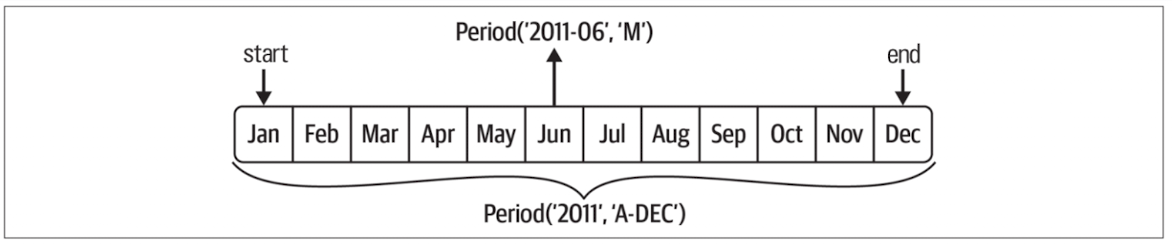

In [89]:
p = pd.Period('2011', freq='A-JUN')
p

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/2093323557.py:1: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p = pd.Period('2011', freq='A-JUN')


Period('2011', 'Y-JUN')

In [90]:
p.asfreq('M', how='start')

Period('2010-07', 'M')

In [91]:
p.asfreq('M', how='end')

Period('2011-06', 'M')

在将高频率转换为低频率时，根据父周期的归属情况，pandas确定了周期。例如，在A-JUN频率中，月份Aug-2011实际上是属于周期2012的：

In [92]:
p = pd.Period('Aug-2011', freq='M')
p.asfreq('A-JUN')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/2958682770.py:2: FutureWarning: 'A-JUN' is deprecated and will be removed in a future version, please use 'Y-JUN' instead.
  p.asfreq('A-JUN')


Period('2012', 'Y-JUN')

完整的PeriodIndex或时间序列也可以用相同的语法进行转换：

In [93]:
periods = pd.period_range('2006', '2009', freq='A-DEC')
periods

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/719350868.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  periods = pd.period_range('2006', '2009', freq='A-DEC')


PeriodIndex(['2006', '2007', '2008', '2009'], dtype='period[Y-DEC]')

In [94]:
ts = pd.Series(np.random.standard_normal(len(periods)), index=periods)
ts

2006   -0.134934
2007    0.870522
2008    1.531615
2009    0.501173
Freq: Y-DEC, dtype: float64

In [95]:
ts.asfreq('M', how='start')

2006-01   -0.134934
2007-01    0.870522
2008-01    1.531615
2009-01    0.501173
Freq: M, dtype: float64

这里，根据年度周期的第一个月，年度周期被替换为月度周期。如果我们想要每年的最后一个工作日，可以使用频率"B"，并指明想要周期的末尾：

In [97]:
ts.asfreq(freq='B', how='end')

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/2506330133.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq(freq='B', how='end')


2006-12-29   -0.134934
2007-12-31    0.870522
2008-12-31    1.531615
2009-12-31    0.501173
Freq: B, dtype: float64

### 11.5.2 季度周期频率

季度数据在会计、金融等领域很常见。许多季度数据都会涉及“财年末”的概念，通常是一年12个月中某月的最后一个日历日或工作日。就这一点来说，周期2012Q4根据财年末的不同会有不同的含义。pandas支持12种可能的季度频率，即Q-JAN到Q-DEC：

In [98]:
p = pd.Period('2012Q4', freq='Q-JAN')
p

Period('2012Q4', 'Q-JAN')

在以1月结束的财年中，2012Q4是从2011年11月到2012年1月。为了验证，可以将其转换为日型频率：

In [99]:
p.asfreq('D', how='start')

Period('2011-11-01', 'D')

In [100]:
p.asfreq('D', how='end')

Period('2012-01-31', 'D')

![图11-2 不同季度频率之间的转换.png](<attachment:图11-2 不同季度频率之间的转换.png>)
因此，可以进行周期之间的算术运算。例如，要获取该季度倒数第二个工作日下午4点的时间戳，可以这样做：
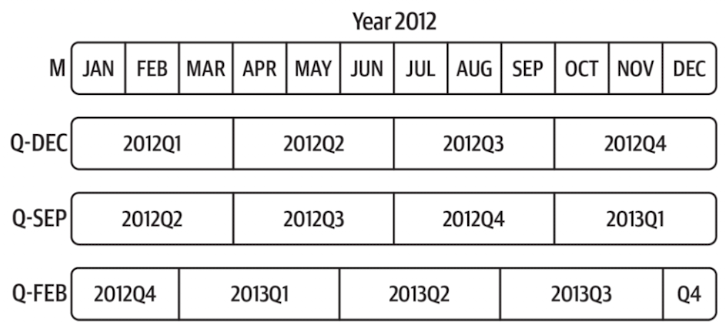

In [101]:
p4pm = (p.asfreq('B', how='end') - 1).asfreq('T', how='start') + 16 * 60
p4pm

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1073398209.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm = (p.asfreq('B', how='end') - 1).asfreq('T', how='start') + 16 * 60
/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1073398209.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p4pm = (p.asfreq('B', how='end') - 1).asfreq('T', how='start') + 16 * 60


Period('2012-01-30 16:00', 'min')

In [102]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

to_timestamp默认返回的是周期开始的Timestamp。

pandas.period_range可用于生成季度时间范围。季度时间范围的算术运算跟上面是一样的：

In [103]:
periods = pd.period_range('2011Q3', '2012Q4', freq='Q-JAN')
ts = pd.Series(np.random.randn(len(periods)), periods)
ts

2011Q3   -0.826789
2011Q4   -1.150044
2012Q1    1.520362
2012Q2    1.149447
2012Q3    1.278554
2012Q4   -0.200046
Freq: Q-JAN, dtype: float64

In [107]:
new_periods = (periods.asfreq('B', how='end')-1).asfreq('H', 'start') + 16
ts.index = new_periods.to_timestamp()
ts

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/4052434821.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods = (periods.asfreq('B', how='end')-1).asfreq('H', 'start') + 16
/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/4052434821.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_periods = (periods.asfreq('B', how='end')-1).asfreq('H', 'start') + 16


2010-10-28 16:00:00   -0.826789
2011-01-28 16:00:00   -1.150044
2011-04-28 16:00:00    1.520362
2011-07-28 16:00:00    1.149447
2011-10-28 16:00:00    1.278554
2012-01-30 16:00:00   -0.200046
dtype: float64

### 11.5.3 时间戳和周期的相互转换

通过使用to_period方法，可以将由时间戳索引的Series和DataFrame对象转换为以周期作为索引：

In [108]:
dates = pd.date_range('2000-01-01', periods=3, freq='M')
dates

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1857975020.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2000-01-01', periods=3, freq='M')


DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31'], dtype='datetime64[ns]', freq='ME')

In [109]:
ts = pd.Series(np.random.randn(len(dates)), index=dates)
ts

2000-01-31    0.592691
2000-02-29    1.200962
2000-03-31    1.036536
Freq: ME, dtype: float64

In [110]:
pts = ts.to_period()
pts

2000-01    0.592691
2000-02    1.200962
2000-03    1.036536
Freq: M, dtype: float64

由于周期指的是非重叠时间段，因此对于给定的频率，一个时间戳只能属于一个周期。新PeriodIndex的频率默认是从时间戳推断而来的，你也可以指定任何支持的频率（支持表11-4中列出的大部分频率）。结果中允许存在重复周期：

In [111]:
dates = pd.date_range('2000-01-29', periods=6)
dates

DatetimeIndex(['2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01',
               '2000-02-02', '2000-02-03'],
              dtype='datetime64[ns]', freq='D')

In [112]:
ts2 = pd.Series(np.random.randn(len(dates)), index=dates)
ts2

2000-01-29   -0.759858
2000-01-30   -1.701665
2000-01-31    1.203384
2000-02-01   -0.323711
2000-02-02   -1.997921
2000-02-03    0.839152
Freq: D, dtype: float64

In [113]:
ts2.to_period('M')

2000-01   -0.759858
2000-01   -1.701665
2000-01    1.203384
2000-02   -0.323711
2000-02   -1.997921
2000-02    0.839152
Freq: M, dtype: float64

要转换回时间戳，使用to_timestamp即可，返回的是DatetimeIndex：

In [114]:
pts = ts2.to_period()
pts

2000-01-29   -0.759858
2000-01-30   -1.701665
2000-01-31    1.203384
2000-02-01   -0.323711
2000-02-02   -1.997921
2000-02-03    0.839152
Freq: D, dtype: float64

In [115]:
pts.to_timestamp(how='end')

2000-01-29 23:59:59.999999999   -0.759858
2000-01-30 23:59:59.999999999   -1.701665
2000-01-31 23:59:59.999999999    1.203384
2000-02-01 23:59:59.999999999   -0.323711
2000-02-02 23:59:59.999999999   -1.997921
2000-02-03 23:59:59.999999999    0.839152
Freq: D, dtype: float64

### 11.5.4 通过数组创建PeriodIndex

固定频率的数据集通常会将时间信息分开存放在多个列中。例如，在下面这个宏观经济数据集中，年度数据集和季度数据集就分别存放在不同的列中：

In [116]:
data = pd.read_csv('examples/macrodata.csv')
data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [118]:
data['year']

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [119]:
data['quarter']

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

通过将这些数组以及一个频率传入PeriodIndex，就可以将它们合并成DataFrame的索引：


In [121]:
index = pd.PeriodIndex(year=data['year'], quarter=data['quarter'], freq='Q-DEC')
index

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/1196282613.py:1: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  index = pd.PeriodIndex(year=data['year'], quarter=data['quarter'], freq='Q-DEC')


PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [122]:
data.index = index
data['infl']

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

## 11.6 重采样及频率转换

重采样指的是将时间序列从一个频率转换到另一个频率的处理过程。将高频率数据连接到低频率称为降采样，而将低频率数据转换到高频率则称为升采样。并不是所有的重采样都能被划分到这两大类中。例如，将W-WED（每周三）转换为W-FRI既不是降采样也不是升采样。

pandas对象都带有一个resample方法，它是各种频率转换工作的主力函数。resample有一个类似于groupby的API，调用resample可以对数据进行分组，然后调用聚合函数：

In [124]:
dates = pd.date_range('2000-01-01', periods=100)
ts = pd.Series(np.random.randn(len(dates)), index=dates)
ts

2000-01-01   -0.012845
2000-01-02    0.935538
2000-01-03    0.258114
2000-01-04   -1.184347
2000-01-05   -0.277401
                ...   
2000-04-05   -0.587269
2000-04-06    0.748322
2000-04-07   -2.208741
2000-04-08   -0.680399
2000-04-09   -1.050828
Freq: D, Length: 100, dtype: float64

In [129]:
ts.resample('ME').mean()

2000-01-31    0.226884
2000-02-29    0.028525
2000-03-31   -0.011660
2000-04-30   -0.439504
Freq: ME, dtype: float64

In [130]:
ts.resample('ME').mean().to_period()

2000-01    0.226884
2000-02    0.028525
2000-03   -0.011660
2000-04   -0.439504
Freq: M, dtype: float64

resample是一个灵活高效的方法，可用于处理大型时间序列。下面将通过一系列的示例说明其用法。表11-5总结了它的一些参数。
![表11-5 resample方法的参数.png](<attachment:表11-5 resample方法的参数.png>)
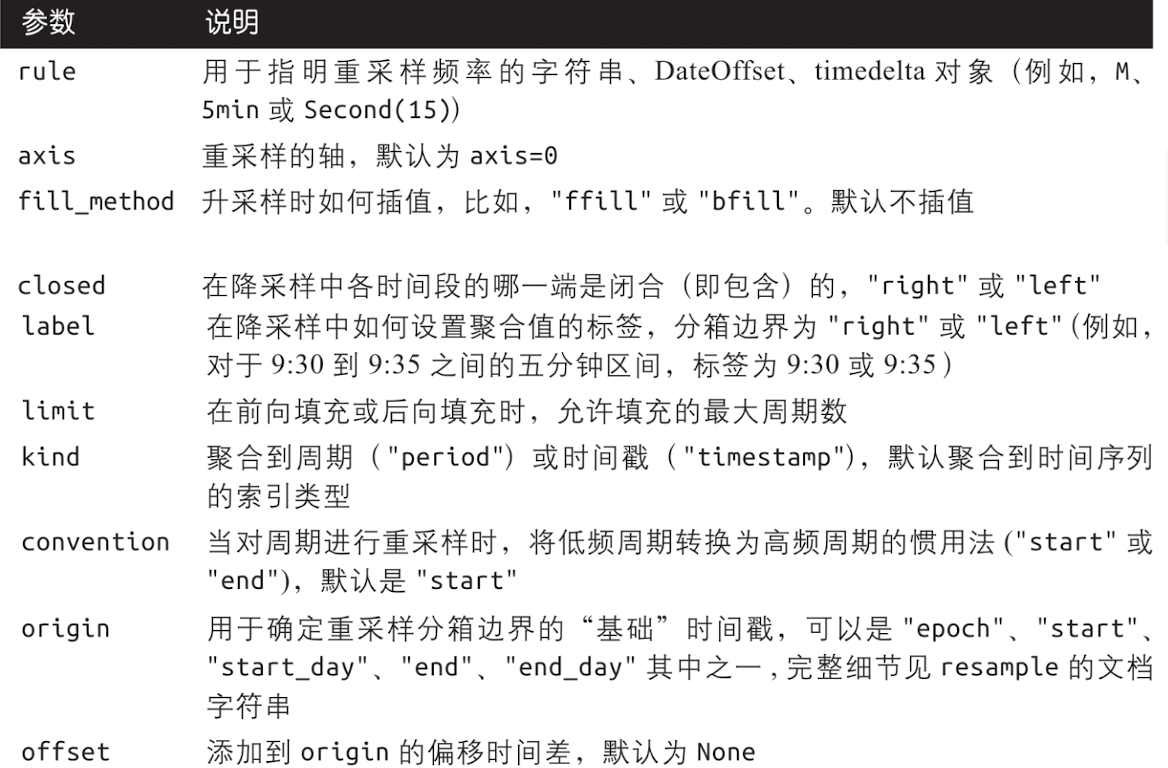

### 11.6.1 降采样

降采样是将数据聚合到规则的低频率。待聚合的数据不必拥有固定的频率，期望的频率会自动定义聚合的分箱边界，这些分箱用于将时间序列拆分为多个片段。例如，要转换到月度频率（"M"或"BM"），数据需要被划分到多个单月时间段中。各时间段都是半开放的。一个数据点只能属于一个时间段，所有时间段的并集必须能组成整个时间范围。在用resample对数据进行降采样时，需要考虑两件事：

- 各区间哪边是闭合的。
- 如何对各个聚合分箱打标签，是用区间的开头还是末尾。

为了说明，我们来看一些频率为一分钟的数据：

In [131]:
dates = pd.date_range('2000-01-01', periods=12, freq='T')

ts = pd.Series(np.random.randn(len(dates)), index=dates)
ts

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/2889829912.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range('2000-01-01', periods=12, freq='T')


2000-01-01 00:00:00    0.108249
2000-01-01 00:01:00   -1.400522
2000-01-01 00:02:00   -1.755131
2000-01-01 00:03:00    0.019541
2000-01-01 00:04:00    1.430753
2000-01-01 00:05:00   -0.176504
2000-01-01 00:06:00   -1.547412
2000-01-01 00:07:00    0.119932
2000-01-01 00:08:00   -0.631793
2000-01-01 00:09:00    0.755173
2000-01-01 00:10:00    0.988354
2000-01-01 00:11:00   -1.629555
Freq: min, dtype: float64

假设你想通过各组求和的方式将这些数据聚合到“五分钟”的数据块或柱状图的柱中：

In [132]:
ts.resample('5min').sum()

2000-01-01 00:00:00   -1.597110
2000-01-01 00:05:00   -1.480604
2000-01-01 00:10:00   -0.641200
Freq: 5min, dtype: float64

传入的频率将会以“五分钟”的增量定义分箱边界。对于这个频率，分箱是默认包含左边界的，因此00:00到00:05的区间是包含00:00的￼。

In [133]:
ts.resample('5min', closed='right').sum()

1999-12-31 23:55:00    0.108249
2000-01-01 00:00:00   -1.881863
2000-01-01 00:05:00   -0.315745
2000-01-01 00:10:00   -1.629555
Freq: 5min, dtype: float64

如你所见，最终的时间序列是以各分箱左边界的时间戳进行标记的。传入label="right"，即可用分箱的右边界对其进行标记：

In [134]:
ts.resample('5min', closed='right', label='right').sum()

2000-01-01 00:00:00    0.108249
2000-01-01 00:05:00   -1.881863
2000-01-01 00:10:00   -0.315745
2000-01-01 00:15:00   -1.629555
Freq: 5min, dtype: float64

如图11-3所示，将频率为一分钟的数据重采样为频率为5分钟的数据。

![图11-3 各种closed、label约定的五分钟重采样示意图.png](<attachment:图11-3 各种closed、label约定的五分钟重采样示意图.png>)
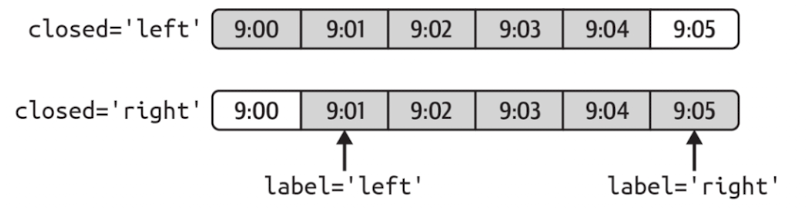

最后，你可能希望对结果索引做一些位移，比如从右边界减去一秒，使其更容易分清该时间戳到底表示的是哪个区间。只需对结果索引添加一个偏移量即可实现：

In [135]:
from pandas.tseries.frequencies import to_offset

result = ts.resample('5min', closed='right', label='right').sum()
result.index = result.index + to_offset('-1s')
result

1999-12-31 23:59:59    0.108249
2000-01-01 00:04:59   -1.881863
2000-01-01 00:09:59   -0.315745
2000-01-01 00:14:59   -1.629555
Freq: 5min, dtype: float64

**开-高-低-收(OHLC)重采样**

在金融领域，一种常用的时间序列聚合方式是计算各个桶的4个值，即第一个值（open，开盘）、最后一个值（close，收盘）、最大值（high，最高）以及最小值（low，最低）。通过ohlc聚合函数，即可得到一个含有这4种聚合值的DataFrame，整个过程很高效，只需经过一次函数调用：

In [136]:
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts

2000-01-01 00:00:00     9
2000-01-01 00:01:00    10
2000-01-01 00:02:00     3
2000-01-01 00:03:00     2
2000-01-01 00:04:00     0
2000-01-01 00:05:00     6
2000-01-01 00:06:00     1
2000-01-01 00:07:00     5
2000-01-01 00:08:00     4
2000-01-01 00:09:00    11
2000-01-01 00:10:00     7
2000-01-01 00:11:00     8
Freq: min, dtype: int64

In [137]:
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 00:00:00,9,10,0,0
2000-01-01 00:05:00,6,11,1,11
2000-01-01 00:10:00,7,8,7,8


### 11.6.2 升采样和插值

升采样是将数据从低频率转换为高频率，不需要做聚合。来看一个带有每周数据的DataFrame：

In [138]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                      index=pd.date_range('1/1/2000', periods=2, freq='W-WED'),
                      columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.238125,0.584909,-1.548101,0.159026
2000-01-12,-0.438648,-1.582208,0.322447,0.006350


当你对这个数据使用聚合函数时，每组只有一个值，这样就会在间隙导入缺失值。我们使用asfreq方法将其转换为高频率数据，不需要做聚合操作：

In [139]:
df_daily = frame.resample('D').asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.238125,0.584909,-1.548101,0.159026
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.438648,-1.582208,0.322447,0.006350


当你对这个数据使用聚合函数时，每组只有一个值，这样就会在间隙导入缺失值。我们使用asfreq方法将其转换为高频率数据，不需要做聚合操作：

In [140]:
frame.resample('D').ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.238125,0.584909,-1.548101,0.159026
2000-01-06,-0.238125,0.584909,-1.548101,0.159026
2000-01-07,-0.238125,0.584909,-1.548101,0.159026
2000-01-08,-0.238125,0.584909,-1.548101,0.159026
2000-01-09,-0.238125,0.584909,-1.548101,0.159026
2000-01-10,-0.238125,0.584909,-1.548101,0.159026
2000-01-11,-0.238125,0.584909,-1.548101,0.159026
2000-01-12,-0.438648,-1.582208,0.322447,0.006350


同样，这里也可以只填充指定的周期数，以限制观测值的持续范围：

In [141]:
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.238125,0.584909,-1.548101,0.159026
2000-01-06,-0.238125,0.584909,-1.548101,0.159026
2000-01-07,-0.238125,0.584909,-1.548101,0.159026
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.438648,-1.582208,0.322447,0.006350


注意，新的日期索引不必与旧的索引重叠：

In [142]:
frame.resample('W-THU').ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.238125,0.584909,-1.548101,0.159026
2000-01-13,-0.438648,-1.582208,0.322447,0.006350


### 11.6.3 使用周期进行重采样

对使用周期作为索引的数据进行重采样，与时间戳的情况类似：

In [143]:
frame = pd.DataFrame(np.random.randn(24, 4),
                    index=pd.period_range('1-2000', '12-2001', freq='M'),
                    columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01,0.015605,1.180869,-0.351245,-0.429117
2000-02,-0.609836,-1.409014,0.326133,-0.361575
2000-03,-2.540744,1.231766,-0.114084,-1.715635
2000-04,0.416900,-0.550213,2.103312,-0.113642
2000-05,1.295697,1.015686,-2.007591,-1.296280
2000-06,0.014161,-0.667198,0.476618,-1.085979
2000-07,-0.392198,0.271359,1.049103,0.643377
2000-08,-1.413315,-2.104690,0.056747,0.028470
2000-09,0.084879,1.734793,-1.113537,2.336946
2000-10,-0.725731,-1.075342,-1.036322,0.162291


In [144]:
annual_frame = frame.resample('A-DEC').mean()
annual_frame

/var/folders/c5/vh03t8zn4797kc18lgrjtcbr0000gn/T/ipykernel_19312/198437850.py:1: FutureWarning: 'A-DEC' is deprecated and will be removed in a future version, please use 'Y-DEC' instead.
  annual_frame = frame.resample('A-DEC').mean()


,Colorado,Texas,New York,Ohio
2000,-0.249967,-0.051205,-0.226901,-0.221045
2001,0.023393,0.101271,0.148387,0.047488


升采样要稍微麻烦一些，在重采样之前，你必须决定在新频率时间段的哪一端放置数值。参数convention默认为"start"，也可设置为"end"：


In [145]:
annual_frame.resample('Q-DEC').ffill()

,Colorado,Texas,New York,Ohio
2000Q1,-0.249967,-0.051205,-0.226901,-0.221045
2000Q2,-0.249967,-0.051205,-0.226901,-0.221045
2000Q3,-0.249967,-0.051205,-0.226901,-0.221045
2000Q4,-0.249967,-0.051205,-0.226901,-0.221045
2001Q1,0.023393,0.101271,0.148387,0.047488
2001Q2,0.023393,0.101271,0.148387,0.047488
2001Q3,0.023393,0.101271,0.148387,0.047488
2001Q4,0.023393,0.101271,0.148387,0.047488


In [146]:
annual_frame.resample('Q-DEC', convention='end').asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,-0.249967,-0.051205,-0.226901,-0.221045
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,0.023393,0.101271,0.148387,0.047488


由于周期指的是时间段，因此升采样和降采样的规则比较严格：
- 在降采样中，目标频率必须是频率源的子周期。
- 在升采样中，目标频率必须是频率源的父周期。

如果不满足这些条件，就会引发异常。这主要会影响季度、年度、每周的频率。例如，由Q-MAR定义的时间段只能和A-MAR、A-JUN、A-SEP、A-DEC对齐：

In [147]:
annual_frame.resample('Q-MAR').ffill()

,Colorado,Texas,New York,Ohio
2000Q4,-0.249967,-0.051205,-0.226901,-0.221045
2001Q1,-0.249967,-0.051205,-0.226901,-0.221045
2001Q2,-0.249967,-0.051205,-0.226901,-0.221045
2001Q3,-0.249967,-0.051205,-0.226901,-0.221045
2001Q4,0.023393,0.101271,0.148387,0.047488
2002Q1,0.023393,0.101271,0.148387,0.047488
2002Q2,0.023393,0.101271,0.148387,0.047488
2002Q3,0.023393,0.101271,0.148387,0.047488


### 11.6.4 对分组时间进行重采样

对于时间序列数据，从语义上讲，resample方法实质是基于时间间隔的分组运算。下面是一个简单的示例：

In [148]:
N = 15
times = pd.date_range('2017-05-20 00:00', freq='1min', periods=N)
df = pd.DataFrame({"time": times, "value": np.arange(N)})

df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


可以根据"time"进行索引，然后进行重采样：

In [149]:
df.set_index('time').resample('5min').count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


假设DataFrame包含多组时间序列和一列分组键，如下所示：

In [ ]:
df2 = pd.DataFrame({"time": times.repeat(3),
                    'key': np.tile(['a', 'b', 'c'], N),
    'value': np.random.randn(N * 3),
})
df2

,time,key,value
0,2017-05-20 00:00:00,a,-0.837411
1,2017-05-20 00:00:00,b,0.908878
2,2017-05-20 00:00:00,c,1.298121
3,2017-05-20 00:01:00,a,0.908684
4,2017-05-20 00:01:00,b,-0.528661
5,2017-05-20 00:01:00,c,-0.925005
6,2017-05-20 00:02:00,a,0.168052
7,2017-05-20 00:02:00,b,-0.495164
8,2017-05-20 00:02:00,c,0.460232
9,2017-05-20 00:03:00,a,-0.135976


为了对各个"key"值做相同的重采样，引入pandas.Grouper对象：

In [154]:
time_key = pd.Grouper(freq='5min')

接下来设置时间索引，以"key"和time_key进行分组，并进行聚合：

In [155]:
resampled = (df2.set_index('time')
               .groupby(['key', time_key])
               .sum())
               
resampled

value
key time                         
a   2017-05-20 00:00:00  0.970374
    2017-05-20 00:05:00  2.808398
    2017-05-20 00:10:00 -1.384377
b   2017-05-20 00:00:00 -2.314173
    2017-05-20 00:05:00  1.367182
    2017-05-20 00:10:00 -1.247788
c   2017-05-20 00:00:00 -0.164890
    2017-05-20 00:05:00 -2.303254
    2017-05-20 00:10:00 -0.548554

In [156]:
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,0.970374
1,a,2017-05-20 00:05:00,2.808398
2,a,2017-05-20 00:10:00,-1.384377
3,b,2017-05-20 00:00:00,-2.314173
4,b,2017-05-20 00:05:00,1.367182
5,b,2017-05-20 00:10:00,-1.247788
6,c,2017-05-20 00:00:00,-0.164890
7,c,2017-05-20 00:05:00,-2.303254
8,c,2017-05-20 00:10:00,-0.548554


使用pandas.Grouper存在一个限制，即必须使用时间作为Series或DataFrame的索引。

## 11.7 移动窗口函数

在移动窗口或指数衰减权重上进行统计或运行其他函数，也是一类常见于时间序列的数组变换。这对于圆滑噪声数据或不连续数据很有帮助。我将其称为移动窗口函数，尽管其中还包括没有固定长度窗口的函数（比如指数加权移动均值）。与其他统计函数一样，移动窗口函数也会自动排除缺失数据。

开始之前，我们加载一些时间序列数据，并将其重采样为工作日频率：

In [157]:
close_px_all = pd.read_csv('examples/stock_px.csv',
                           parse_dates=True, index_col=0)
close_px_all

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93
...,...,...,...,...
2011-10-10,388.81,26.94,76.28,1194.89
2011-10-11,400.29,27.00,76.27,1195.54
2011-10-12,402.19,26.96,77.16,1207.25
2011-10-13,408.43,27.18,76.37,1203.66


In [158]:
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


In [159]:
close_px = close_px.resample('B').ffill()
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


现在导入rolling运算符，它与resample和groupby很像。通过一个window（表示周期的数量，见图11-4），可以在Series或DataFrame上调用它：


<Axes: >

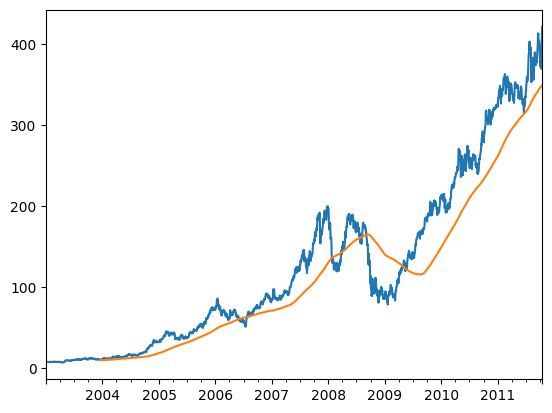

In [161]:
close_px['AAPL'].plot()
close_px['AAPL'].rolling(250).mean().plot(label='AAPL')

表达式rolling(250)与groupby很像，但它不是进行分组，而是创建一个可以按照250日分组的移动窗口对象。然后，我们就得到了苹果公司股价的250日移动窗口。

默认情况下，滚动函数需要窗口中所有的值为非NA值，可以修改此行为以解决缺失数据的问题。特别是，实际上在时间序列开始处，数据量就低于window周期数（如图11-5所示）：

In [162]:
from matplotlib import pyplot as plt

plt.figure()
std250 = close_px['AAPL'].pct_change().rolling(250, min_periods=10).std()
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

<Figure size 640x480 with 0 Axes>

<Axes: >

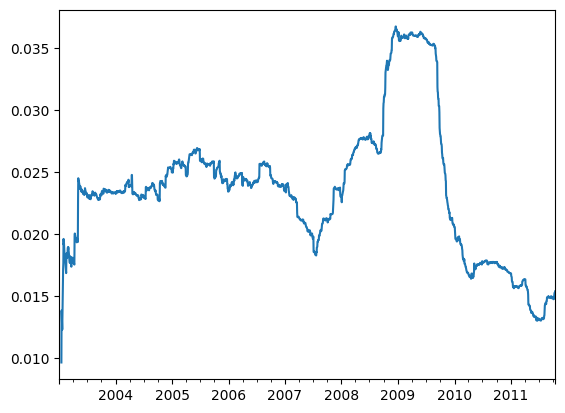

In [163]:
std250.plot()

要计算扩展窗口平均值，不使用rolling，而是使用expanding运算符。使用与滚动窗口相同的起始点，扩展窗口平均值开启时间窗口后持续增加窗口大小，直到涵盖整个序列。std250时间序列的扩展窗口平均值如下所示：

<Axes: >

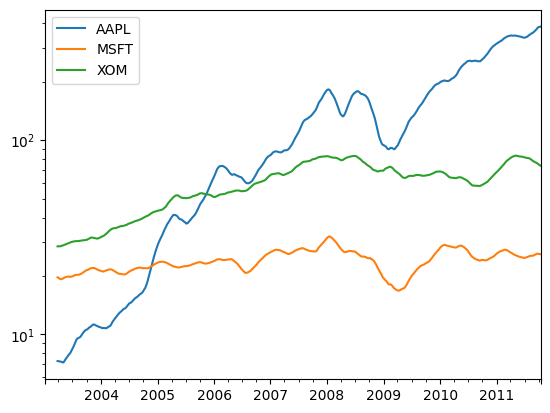

In [164]:
expanding_mean = std250.expanding().mean()
close_px.rolling(60).mean().plot(logy=True)

rolling函数也可以接收一个字符串，而非一组周期数字，用于给移动窗口函数的rolling()指定固定大小的时间偏移量。使用字符串可以方便地处理不规则的时间序列。这些字符串也可以传递给resample。例如，可以计算20天的滚动均值，如下所示：

In [165]:
close_px.rolling('20D').mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


### 11.7,1 指数加权函数

另一种使用固定大小窗口及相等权重观测值的办法，是定义一个衰减因子常量，以给予最近的观测值更大的权重。衰减因子的定义方式有很多，比较流行的是使用时间段的方式，它可以使结果类似于一个简单的移动窗口函数，且窗口大小等于时间段。

由于指数加权统计会赋予近期观测值更大的权重，因此相对于等权统计，它对变化“适应”得更快。
除了rolling和expanding，pandas还有ewm运算符（ewm表示指数加权移动）。下面的例子对比了苹果公司股价的30日移动均值和span=60的指数加权移动均值（如图11-7所示）：

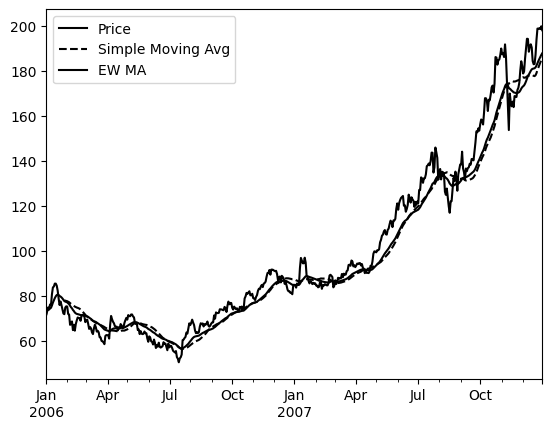

In [167]:
aapl_px = close_px['AAPL']["2006":"2007"]
ma30 = aapl_px.rolling(30, min_periods=20).mean()
ewma30 = aapl_px.ewm(span=30).mean()
aapl_px.plot(style='k', label='Price')
ma30.plot(style='k--', label='Simple Moving Avg')
ewma30.plot(style='k-', label='EW MA')
plt.legend()

### 11.7.2 二元移动窗口函数

有些统计运算（如相关系数和协方差）需要在两个时间序列上执行。例如，金融分析师通常对某只股票与某个基准指数（如标准普尔500指数）的相关系数感兴趣。要进行说明，我们先计算所有我们感兴趣的时间序列的百分比变化：

In [168]:
spx_ps = close_px_all['SPX']
spx_rets = spx_ps.pct_change()
returns = close_px.pct_change()

调用rolling之后，corr聚合函数开始计算spx_rets的滚动相关系数（结果如图11-8所示）：

<Axes: >

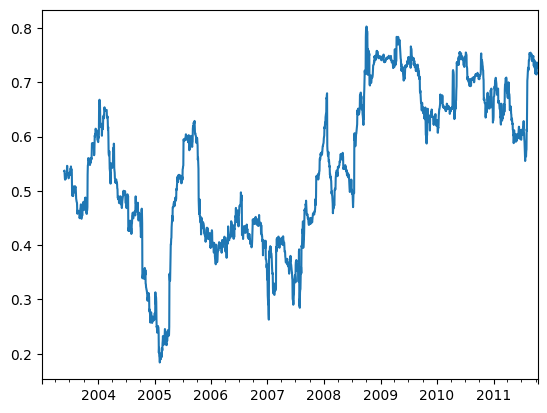

In [169]:
corr = returns['AAPL'].rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

假设你想一次性计算多只股票与标准普尔500指数的相关系数，可以编写一个循环，像对苹果股票那样，对每只股票进行计算。但如果每只股票都是DataFrame中的一列，我们只需对DataFrame和传入的Series spx_rets调用rolling，就可以一次性计算出所有的滚动相关系数（结果如图11-9所示）：

<Axes: >

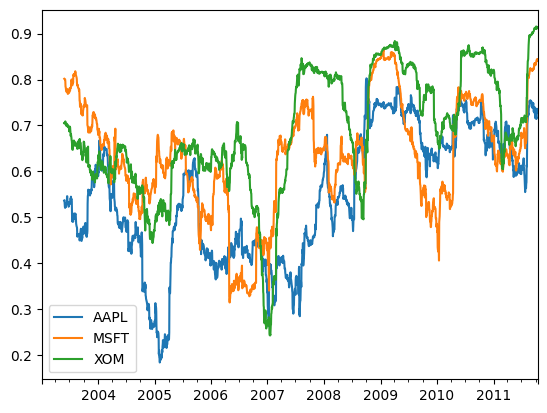

In [171]:
corr = returns.rolling(125, min_periods=100).corr(spx_rets)
corr.plot()

### 11.7.3 用户自定义的移动窗口函数

在rolling及其相关方法上使用apply方法，提供了一种能够在移动窗口上应用自己定义的数组函数的途径。唯一的要求是该函数要能从数组的各个片段中产生单个值（即约简）。例如，当我们用rolling(...).quantile(q)计算样本分位数时，可能对样本中特定值的百分等级感兴趣。scipy.stats.percentileofscore函数就能实现这个目的（结果如图11-10所示）：

<Axes: >

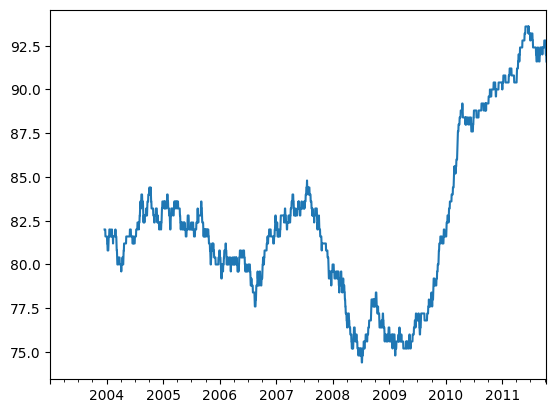

In [172]:
from scipy.stats import percentileofscore

def score_at_2percent(x):
    return percentileofscore(x, 0.02)

result = returns['AAPL'].rolling(250).apply(score_at_2percent)
result.plot()